<a href="https://colab.research.google.com/github/princealexanderm/-ICT_AI_ML/blob/main/ICT_AI_ML__Assignment_03_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 03_Classification

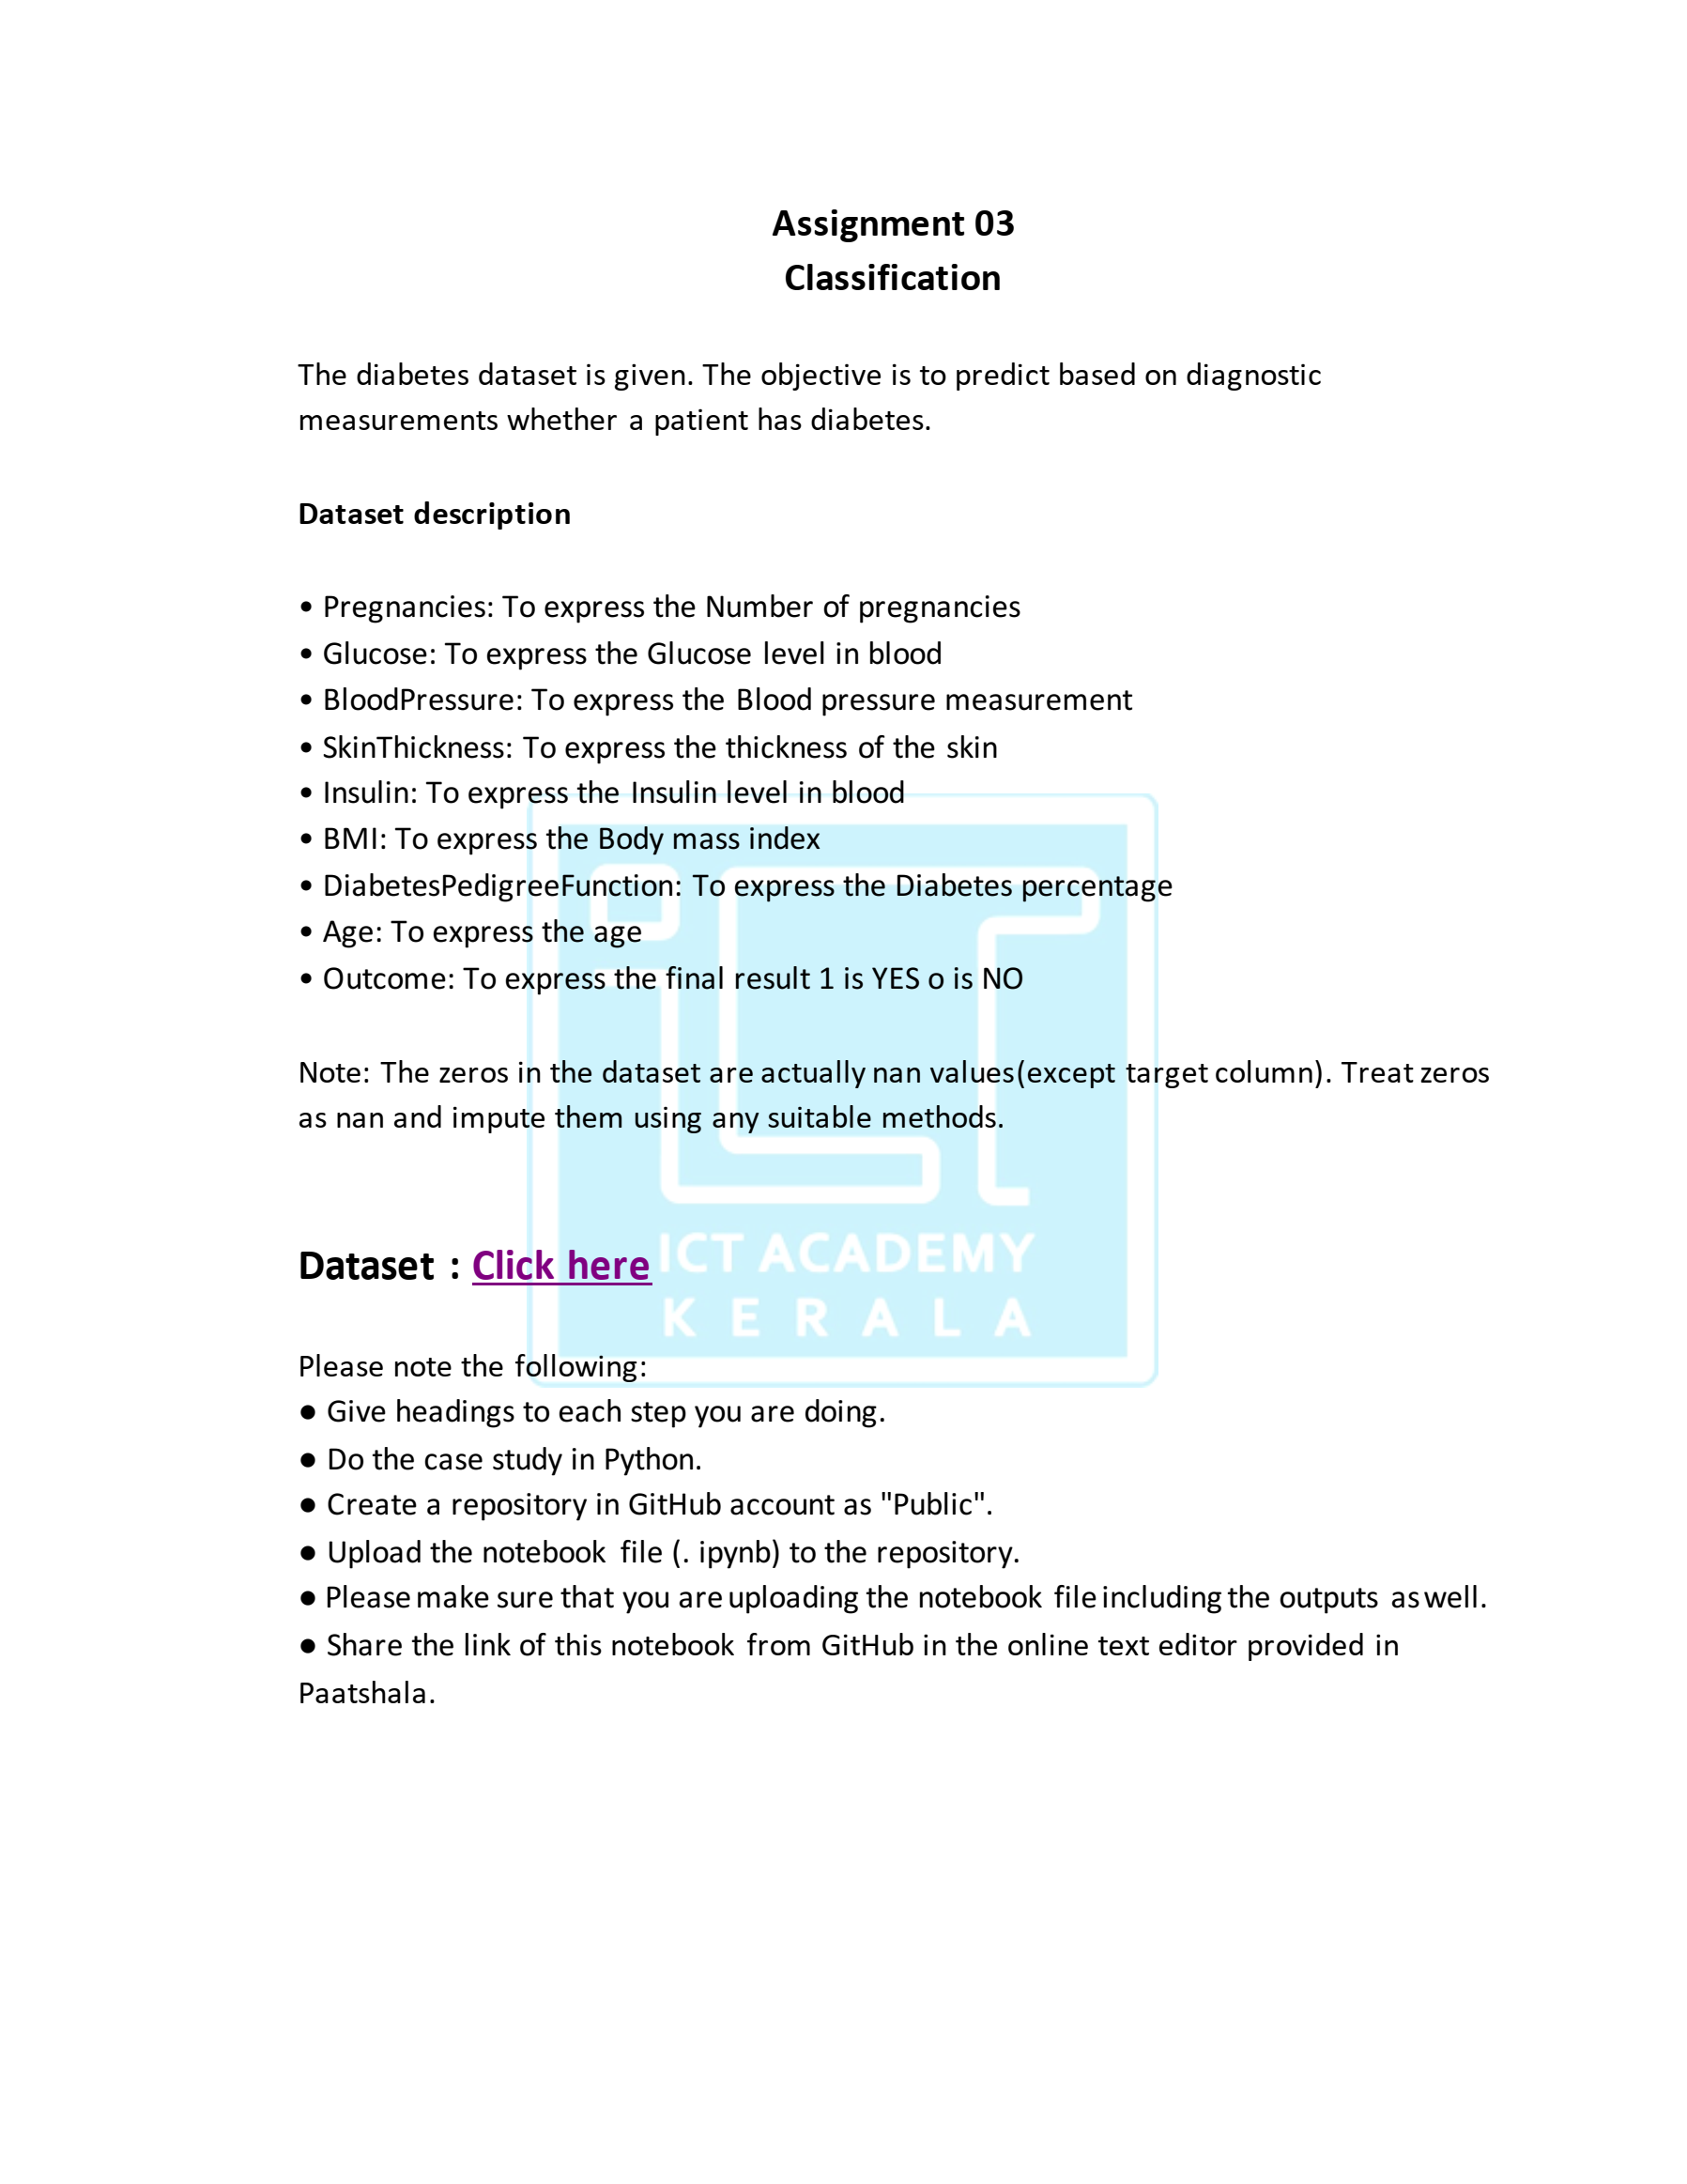

# 1. import modules

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#2. Load data

In [108]:
df=pd.read_csv('/content/diabetes.csv')
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [109]:
df.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
471,0,137,70,38,0,33.2,0.170,22,0
457,5,86,68,28,71,30.2,0.364,24,0
254,12,92,62,7,258,27.6,0.926,44,1
275,2,100,70,52,57,40.5,0.677,25,0
646,1,167,74,17,144,23.4,0.447,33,1
581,6,109,60,27,0,25.0,0.206,27,0
266,0,138,0,0,0,36.3,0.933,25,1
72,13,126,90,0,0,43.4,0.583,42,1
218,5,85,74,22,0,29.0,1.224,32,1
319,6,194,78,0,0,23.5,0.129,59,1


In [110]:
df. size

6912

In [111]:
df.shape

(768, 9)

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# No categorical data

In [113]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [114]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


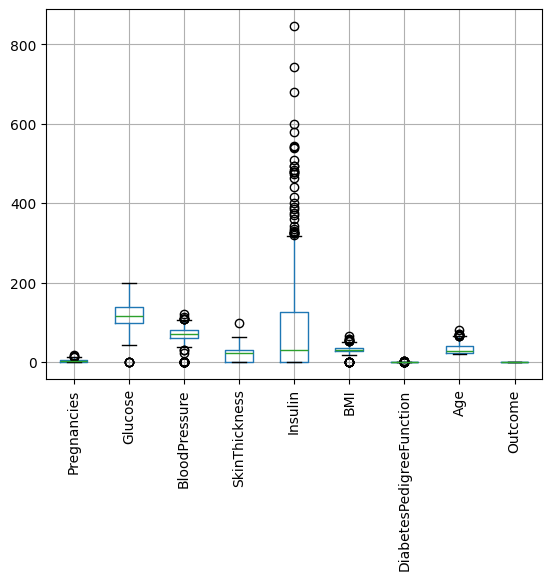

In [115]:
df.boxplot()
plt.xticks(rotation=90)
plt.show()

In [116]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


<Axes: >

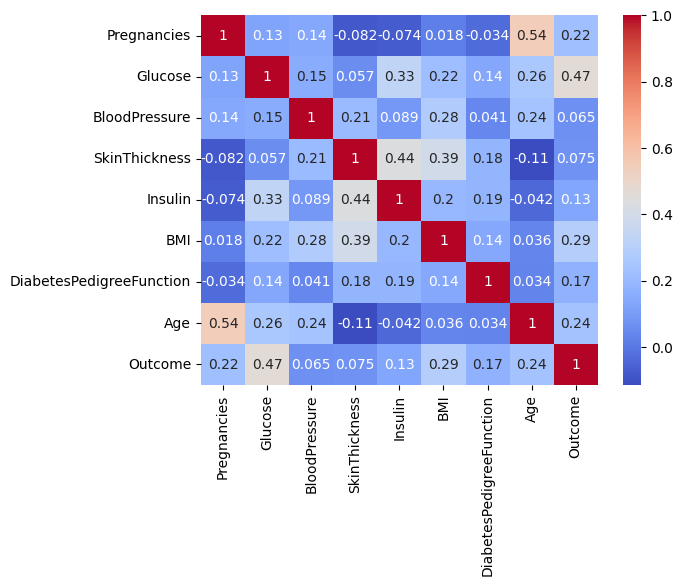

In [117]:
corr_matrix=df.corr()
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')

seems like Blood pressure and skin thickness have not much role in outcome.

In [118]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

# Relacing all 0 in independent variables with NaN

In [119]:
target_column = 'Outcome'
for column in df.columns:
    if column != target_column:
        df[column] = df[column].replace(0, np.nan)

In [120]:
df.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
184,4.0,141.0,74.0,NaN,NaN,27.6,0.244,40,0
200,NaN,113.0,80.0,16.0,NaN,31.0,0.874,21,0
551,3.0,84.0,68.0,30.0,106.0,31.9,0.591,25,0
213,NaN,140.0,65.0,26.0,130.0,42.6,0.431,24,1
483,NaN,84.0,82.0,31.0,125.0,38.2,0.233,23,0
269,2.0,146.0,NaN,NaN,NaN,27.5,0.240,28,1
704,4.0,110.0,76.0,20.0,100.0,28.4,0.118,27,0
286,5.0,155.0,84.0,44.0,545.0,38.7,0.619,34,0
653,2.0,120.0,54.0,NaN,NaN,26.8,0.455,27,0
714,3.0,102.0,74.0,NaN,NaN,29.5,0.121,32,0


#Split the seperate the target and independent variable

In [121]:
x=df.drop(['Outcome'],axis=1)
#x=df.drop(['BloodPressure','SkinThickness','Outcome'],axis=1)
y=df['Outcome']

In [122]:
x.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.0,NaN,33.6,0.627,50
1,1.0,85.0,66.0,29.0,NaN,26.6,0.351,31
2,8.0,183.0,64.0,NaN,NaN,23.3,0.672,32
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21
4,NaN,137.0,40.0,35.0,168.0,43.1,2.288,33


In [123]:
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


In [124]:
x['Pregnancies'].nunique()

16

In [125]:
x['Pregnancies'].unique()

array([ 6.,  1.,  8., nan,  5.,  3., 10.,  2.,  4.,  7.,  9., 11., 13.,
       15., 17., 12., 14.])

In [126]:
x['Pregnancies'].value_counts()

,count
Pregnancies,
1.0,135
2.0,103
3.0,75
4.0,68
5.0,57
6.0,50
7.0,45
8.0,38
9.0,28


In [127]:
x.isnull().sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0


No null values in
- DiabetesPedigreeFunction
- Age

In [128]:
x.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

# Filling null values with mode

In [129]:
x['Pregnancies'].fillna(x['Pregnancies'].mode()[0],inplace=True)
x['Glucose'].fillna(x['Glucose'].mode()[0],inplace=True)
x['BloodPressure'].fillna(x['BloodPressure'].mode()[0],inplace=True)
x['SkinThickness'].fillna(x['SkinThickness'].mode()[0],inplace=True)
x['Insulin'].fillna(x['Insulin'].mode()[0],inplace=True)

<ipython-input-129-5abc595d0033>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x['Pregnancies'].fillna(x['Pregnancies'].mode()[0],inplace=True)
<ipython-input-129-5abc595d0033>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

# Filling null values with mean

In [130]:
x['BMI'].fillna(x['BMI'].mean(),inplace=True)

<ipython-input-130-5f1bb10047ec>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x['BMI'].fillna(x['BMI'].mean(),inplace=True)


In [131]:
x.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0


#Split the x data for training and testing

In [132]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [133]:
X_train.shape

(614, 8)

In [134]:
X_test.shape

(154, 8)

#model-1:Logistic Regression

In [135]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(X_train,y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [136]:
y_pred_lr=lr.predict(X_test)

# Model Evaluation

In [137]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score,f1_score
print('Accuracy is', accuracy_score(y_test, y_pred_lr))
print('Precision is', precision_score(y_test, y_pred_lr))
print('Recall is', recall_score(y_test, y_pred_lr))
print('f1 score is', f1_score(y_test,y_pred_lr))

Accuracy is 0.7727272727272727
Precision is 0.6923076923076923
Recall is 0.6545454545454545
f1 score is 0.6728971962616822


In [138]:
confusion_matrix(y_test,y_pred_lr)

array([[83, 16],
       [19, 36]])

# Testing result

In [139]:
y_pred_lr

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [161]:
y_test[0:10]

,Outcome
668,0
324,0
624,0
690,0
473,0
204,0
97,0
336,0
568,0
148,0


In [141]:
y_pred_lr_a = np.where(y_pred_lr == 1, 'yes', 'no')
y_pred_lr_a

array(['no', 'no', 'no', 'no', 'no', 'no', 'no', 'yes', 'yes', 'yes',
       'no', 'yes', 'no', 'no', 'no', 'yes', 'no', 'no', 'yes', 'yes',
       'no', 'no', 'no', 'no', 'yes', 'yes', 'no', 'no', 'no', 'no',
       'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'no', 'no', 'no',
       'no', 'yes', 'no', 'no', 'no', 'yes', 'yes', 'no', 'no', 'yes',
       'no', 'yes', 'yes', 'no', 'no', 'no', 'yes', 'no', 'yes', 'yes',
       'yes', 'no', 'no', 'no', 'no', 'yes', 'no', 'yes', 'no', 'yes',
       'yes', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'yes',
       'no', 'no', 'no', 'no', 'yes', 'yes', 'no', 'no', 'no', 'no', 'no',
       'no', 'no', 'yes', 'yes', 'no', 'no', 'yes', 'no', 'yes', 'no',
       'yes', 'no', 'yes', 'no', 'no', 'yes', 'no', 'yes', 'no', 'no',
       'no', 'yes', 'no', 'no', 'yes', 'no', 'no', 'no', 'no', 'no', 'no',
       'no', 'no', 'no', 'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'no',
       'no', 'yes', 'no', 'no', 'yes', 'yes', 'no', 'no', 'no',

# Trying to improve results after scaling

## Appling StandarScaler

In [142]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_SS=scaler.fit_transform(X_train)
X_test_SS=scaler.transform(X_test)

In [143]:
lr_SS=LogisticRegression()
lr_SS.fit(X_train_SS,y_train)
y_pred_lr_SS=lr_SS.predict(X_test_SS)

In [144]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score,f1_score
print('Accuracy is', accuracy_score(y_test, y_pred_lr_SS))
print('Precision is', precision_score(y_test, y_pred_lr_SS))
print('Recall is', recall_score(y_test, y_pred_lr_SS))
print('f1 score is', f1_score(y_test,y_pred_lr_SS))

Accuracy is 0.7597402597402597
Precision is 0.6730769230769231
Recall is 0.6363636363636364
f1 score is 0.6542056074766355


Not much imporvement

# Model-2:SVM

In [145]:
from sklearn.svm import SVC
svm=SVC()
svm.fit(X_train,y_train)

SVC()

In [146]:
y_pred_svm=svm.predict(X_test)

In [147]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score,f1_score
print('Accuracy is', accuracy_score(y_test, y_pred_svm))
print('Precision is', precision_score(y_test, y_pred_svm))
print('Recall is', recall_score(y_test, y_pred_svm))
print('f1 score is', f1_score(y_test,y_pred_svm))

Accuracy is 0.7727272727272727
Precision is 0.7272727272727273
Recall is 0.5818181818181818
f1 score is 0.6464646464646465


#Model-3:DecisionTree

In [148]:
from sklearn.tree import DecisionTreeClassifier
DT=DecisionTreeClassifier()
DT.fit(X_train,y_train)

DecisionTreeClassifier()

In [149]:
y_pred_DT=DT.predict(X_test)

In [150]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score,f1_score
print('Accuracy is', accuracy_score(y_test, y_pred_DT))
print('Precision is', precision_score(y_test, y_pred_DT))
print('Recall is', recall_score(y_test, y_pred_DT))
print('f1 score is', f1_score(y_test,y_pred_DT))

Accuracy is 0.7012987012987013
Precision is 0.5652173913043478
Recall is 0.7090909090909091
f1 score is 0.6290322580645161


#Model-4:RandomForest

In [151]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(X_train,y_train)

RandomForestClassifier()

In [152]:
y_pred_rf=rf.predict(X_test)

In [153]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score,f1_score
print('Accuracy is', accuracy_score(y_test, y_pred_rf))
print('Precision is', precision_score(y_test, y_pred_rf))
print('Recall is', recall_score(y_test, y_pred_rf))
print('f1 score is', f1_score(y_test,y_pred_rf))

Accuracy is 0.7402597402597403
Precision is 0.631578947368421
Recall is 0.6545454545454545
f1 score is 0.6428571428571429


#Model-5:KNN

In [162]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=1)

In [163]:
y_pred_knn=knn.predict(X_test)

In [164]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score,f1_score
print('Accuracy is', accuracy_score(y_test, y_pred_knn))
print('Precision is', precision_score(y_test, y_pred_knn))
print('Recall is', recall_score(y_test, y_pred_knn))
print('f1 score is', f1_score(y_test,y_pred_knn))

Accuracy is 0.6623376623376623
Precision is 0.5245901639344263
Recall is 0.5818181818181818
f1 score is 0.5517241379310345


---